# Mouse Brain 空间多组学

In [1]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import torch
from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, mean_squared_error
from sklearn.neighbors import NearestNeighbors

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff_improved").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff_improved as sd
from SpaDiff_improved.utils import lsi, set_seed


## 参数

In [2]:
SEED = 42
N_CLUSTERS = 14
N_NEIGHBORS = 10
LATENT_DIM = 50
FAST_DEV_RUN = False

# K1 is the shared-latent DEC regularizer; K2 is bidirectional diffusion DSM.
# The original Mousebrain autoencoder reconstruction objective is a different
# architecture and is not silently substituted here.
K1 = 0.0
K2 = 1.0
DEC_ONLY = K1 > 0.0 and K2 == 0.0

DATA_ROOT = Path("E:/gxy_2/final/0_data/case4/SpatialGLUE/Mouse_Brain")
RNA_FILE = DATA_ROOT / "adata_RNA.h5ad"
ATAC_FILE = DATA_ROOT / "adata_peaks_normalized.h5ad"

print("RNA_FILE =", RNA_FILE)
print("ATAC_FILE =", ATAC_FILE)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)
print(f"loss = {K1} * shared_DEC + {K2} * cross_modal_DSM")


RNA_FILE = E:\gxy_2\final\0_data\case4\SpatialGLUE\Mouse_Brain\adata_RNA.h5ad
ATAC_FILE = E:\gxy_2\final\0_data\case4\SpatialGLUE\Mouse_Brain\adata_peaks_normalized.h5ad
device = cuda:0
loss = 0.0 * shared_DEC + 1.0 * cross_modal_DSM


## 读取数据

In [3]:
adata_rna = sc.read_h5ad(RNA_FILE)
adata_atac = sc.read_h5ad(ATAC_FILE)
adata_rna.var_names_make_unique()
adata_atac.var_names_make_unique()

common_spots = adata_rna.obs_names[adata_rna.obs_names.isin(adata_atac.obs_names)]
if len(common_spots) == 0:
    raise ValueError("RNA 与 ATAC 没有同名 spot；请先建立配对映射")

adata_rna = adata_rna[common_spots].copy()
adata_atac = adata_atac[common_spots].copy()
assert np.array_equal(adata_rna.obs_names, adata_atac.obs_names)
print(f"paired spots: {len(common_spots):,}")


paired spots: 9,215


## RNA PCA 与 ATAC LSI

In [4]:
sc.pp.filter_genes(adata_rna, min_cells=10)
adata_rna.layers["counts"] = adata_rna.X.copy()
sc.pp.highly_variable_genes(
    adata_rna, flavor="seurat_v3", layer="counts", n_top_genes=3000
)
adata_rna = adata_rna[:, adata_rna.var["highly_variable"]].copy()
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.scale(adata_rna, max_value=10)

latent_dim = min(LATENT_DIM, adata_rna.n_obs - 1, adata_rna.n_vars - 1, adata_atac.n_vars - 2)
if latent_dim < 2:
    raise ValueError("可用特征过少，无法构建 PCA/LSI 潜空间")
sc.tl.pca(adata_rna, n_comps=latent_dim, svd_solver="arpack")

if "X_lsi" not in adata_atac.obsm or adata_atac.obsm["X_lsi"].shape[1] != latent_dim:
    lsi(adata_atac, n_components=latent_dim + 1, use_highly_variable=False,random_state=SEED)

X_rna_np = np.asarray(adata_rna.obsm["X_pca"], dtype=np.float32)
X_atac_np = np.asarray(adata_atac.obsm["X_lsi"], dtype=np.float32)[:, :latent_dim]
assert X_rna_np.shape == X_atac_np.shape
print("paired latent shape =", X_rna_np.shape)


paired latent shape = (9215, 50)


## 构建单纯形

In [5]:
coordinates = np.asarray(adata_rna.obsm["spatial"])
k = min(N_NEIGHBORS + 1, adata_rna.n_obs)
knn = NearestNeighbors(n_neighbors=k, metric="euclidean").fit(coordinates)
adjacency = knn.kneighbors_graph(coordinates, mode="connectivity")
adjacency.setdiag(0)
adjacency.eliminate_zeros()
adjacency = adjacency.maximum(adjacency.T)
base_operators_scipy = sd.build_simplicial_operators(adjacency, max_order=2)
base_operators = sd.to_torch_operators(base_operators_scipy, device=device)

X_rna = torch.as_tensor(X_rna_np, dtype=torch.float32, device=device)
X_atac = torch.as_tensor(X_atac_np, dtype=torch.float32, device=device)

print("edge nnz:", base_operators[1]._nnz(), "triangle nnz:", base_operators[2]._nnz())


edge nnz: 109427 triangle nnz: 109427


## 双向跨模态训练

In [6]:
paired_operators_scipy = {
    order: sparse.block_diag((operator, operator), format="csr")
    for order, operator in base_operators_scipy.items()
}

paired_operators = sd.to_torch_operators(paired_operators_scipy, device=device)
target_features = torch.cat((X_rna, X_atac), dim=0)
condition_features = torch.cat((X_atac, X_rna), dim=0)

batch_ids = torch.zeros(2 * adata_rna.n_obs, dtype=torch.long, device=device)
target_modality_ids = torch.cat((
    torch.zeros(adata_rna.n_obs, dtype=torch.long, device=device),
    torch.ones(adata_rna.n_obs, dtype=torch.long, device=device),
))
print("training target:", tuple(target_features.shape))


training target: (18430, 50)


## 训练双向 modality 条件 VP-SDE

In [7]:
config = sd.SpaDiffConfig(
    data_dim=latent_dim,
    condition_input_dim=latent_dim,
    num_batches=1,
    num_modalities=2,
    num_scales=50 if FAST_DEV_RUN else 1000,
    topology_hidden_dim=64,
    topology_dim=64,
    hidden_dim=128,
    dropout=0.5 if K1 > 0.0 else 0.1,
    topology_projection_dropout=0.2 if K1 > 0.0 else None,
    k1=K1,
    k2=K2,
    dec_init_method="kmeans",
    num_clusters=N_CLUSTERS,
    dec_alpha=1.0,
    dec_update_interval=10,
    dec_tolerance=1e-4,
    random_seed=SEED,
)
model = sd.SpaDiff(config).to(device)
training_epochs =200
training = sd.train_spadiff(
    model,
    target_features,
    paired_operators,
    batch_ids,
    target_modality_ids,
    condition_features=condition_features,
    epochs=training_epochs,
    learning_rate=1e-3,
    weight_decay=1e-4,
    ema_decay=None if DEC_ONLY else 0.999,
    verbose_every=1 if FAST_DEV_RUN or DEC_ONLY else 25,
)
print("best total loss =", training.best_loss)
print("last shared DEC loss =", training.original_losses[-1])
print("last diffusion loss =", training.diffusion_losses[-1])


Epoch 0001/200 | total=1.000652 | original=0.000000 | diffusion=1.000652
Epoch 0025/200 | total=0.707443 | original=0.000000 | diffusion=0.707443
Epoch 0050/200 | total=0.507817 | original=0.000000 | diffusion=0.507817
Epoch 0075/200 | total=0.399622 | original=0.000000 | diffusion=0.399622
Epoch 0100/200 | total=0.345742 | original=0.000000 | diffusion=0.345742
Epoch 0125/200 | total=0.318012 | original=0.000000 | diffusion=0.318012
Epoch 0150/200 | total=0.308316 | original=0.000000 | diffusion=0.308316
Epoch 0175/200 | total=0.304857 | original=0.000000 | diffusion=0.304857
Epoch 0200/200 | total=0.297717 | original=0.000000 | diffusion=0.297717
best total loss = 0.29672306776046753
last shared DEC loss = 0.0
last diffusion loss = 0.29771697521209717


In [8]:
## 双向跨模态生成或 DEC-only 融合
single_batch = torch.zeros(adata_rna.n_obs, dtype=torch.long, device=device)
rna_target = torch.zeros_like(single_batch)
atac_target = torch.ones_like(single_batch)

if DEC_ONLY:
    # k2=0 has no diffusion network; use the two shared HiGCN encodings.
    topology_rna = model.encode_condition(X_rna, base_operators)
    topology_atac = model.encode_condition(X_atac, base_operators)
    generated_rna = None
    generated_atac = None
else:
    if training.ema is not None:
        training.ema.store(model.parameters())
        training.ema.copy_to(model.parameters())
    try:
        generated_rna = model.generate(
            X_atac, base_operators, single_batch, rna_target,
            sampler="ode", guidance_scale=1.1,
            ode_steps=20 if FAST_DEV_RUN else 300,
        )
        generated_atac = model.generate(
            X_rna, base_operators, single_batch, atac_target,
            sampler="ode", guidance_scale=1.1,
            ode_steps=20 if FAST_DEV_RUN else 300,
        )
        topology_rna = model.encode_condition(X_rna, base_operators)
        topology_atac = model.encode_condition(X_atac, base_operators)
    finally:
        if training.ema is not None:
            training.ema.restore(model.parameters())

if generated_rna is not None:
    adata_rna.obsm["X_generated_rna_pca"] = generated_rna.cpu().numpy()
    adata_rna.obsm["X_generated_atac_lsi"] = generated_atac.cpu().numpy()
adata_rna.obsm["X_spadiff"] = (0.5 * (topology_rna + topology_atac)).detach().cpu().numpy()


In [9]:
if DEC_ONLY:
    print("K2=0: diffusion generation is disabled; skipping cross-modal MSE/correlation.")
else:
    generated_rna_np = adata_rna.obsm["X_generated_rna_pca"]
    generated_atac_np = adata_rna.obsm["X_generated_atac_lsi"]
    rna_mse = mean_squared_error(X_rna_np, generated_rna_np)
    atac_mse = mean_squared_error(X_atac_np, generated_atac_np)
    rna_corr = np.corrcoef(X_rna_np.ravel(), generated_rna_np.ravel())[0, 1]
    atac_corr = np.corrcoef(X_atac_np.ravel(), generated_atac_np.ravel())[0, 1]
    print(f"ATAC -> RNA | MSE={rna_mse:.4f}, correlation={rna_corr:.4f}")
    print(f"RNA -> ATAC | MSE={atac_mse:.4f}, correlation={atac_corr:.4f}")


ATAC -> RNA | MSE=19358.9004, correlation=0.0018
RNA -> ATAC | MSE=19337.7070, correlation=0.0009


## 空间域识别

未找到已知空间域标签，跳过 ARI。


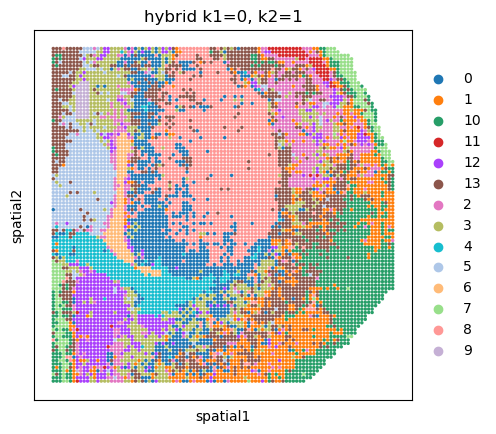

In [10]:
labels = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=SEED).fit_predict(
    adata_rna.obsm["X_spadiff"]
)
adata_rna.obs["SpaDiff_domain"] = pd.Categorical(labels.astype(str))

truth_candidates = ["Truth", "annotation", "cell_type", "ground_truth"]
truth_key = next((key for key in truth_candidates if key in adata_rna.obs), None)
if truth_key is not None:
    valid = adata_rna.obs[[truth_key, "SpaDiff_domain"]].dropna()
    ari = adjusted_rand_score(valid[truth_key], valid["SpaDiff_domain"])
    print(f"{truth_key} ARI = {ari:.3f}")
else:
    ari = None
    print("未找到已知空间域标签，跳过 ARI。")

mode = "DEC-only multimodal" if DEC_ONLY else f"hybrid k1={K1:g}, k2={K2:g}"
title = mode if ari is None else f"{mode} | ARI={ari:.3f}"
sc.pl.spatial(adata_rna, color="SpaDiff_domain", spot_size=1, title=title)
